In [1]:
import zipfile
import os

archive_path = "/content/images.zip"
extract_dir = "/content"

os.makedirs(extract_dir, exist_ok=True)

try:
    with zipfile.ZipFile(archive_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Архив успешно извлечён в {extract_dir}")
except zipfile.BadZipFile:
    print("Ошибка: архив повреждён или не является ZIP-файлом.")
except FileNotFoundError:
    print("Ошибка: архив не найден.")

Архив успешно извлечён в /content


In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image

In [5]:
from PIL import Image
import os
import shutil


image_folder = "/content/images"


organized_folder = "/content/new_images"


os.makedirs(organized_folder, exist_ok=True)


valid_extensions = [".jpg", ".jpeg", ".png", ".gif"]

def is_corrupt_image(image_path):
    try:
        with Image.open(image_path) as img:
            img.verify()
        return False
    except (IOError, SyntaxError):
        return True


for filename in os.listdir(image_folder):

    if any(filename.endswith(ext) for ext in valid_extensions):
        file_path = os.path.join(image_folder, filename)


        if is_corrupt_image(file_path):
            print(f"Skipping corrupt image: {filename}")
            continue

        class_name = filename.split("_")[0]


        class_dir = os.path.join(organized_folder, class_name)
        os.makedirs(class_dir, exist_ok=True)

        try:

            shutil.copy2(file_path, os.path.join(class_dir, filename))
        except Exception as e:
            print(f"Error copying {filename}: {e}")

print(f"Dataset organized in: {organized_folder}")


Dataset organized in: /content/new_images


In [10]:
DATA_ROOT = "/content/new_images"
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_EPOCHS = 15
TRAIN_RATIO = 0.8
NUM_CLASSES = 37


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(
    root=DATA_ROOT,
    transform=train_transform
)

labels = [label for _, label in full_dataset]
sss = StratifiedShuffleSplit(n_splits=1, test_size=1-TRAIN_RATIO, random_state=42)
train_indices, test_indices = next(sss.split(np.zeros(len(labels)), labels))

full_dataset.transform = train_transform
test_dataset = Subset(full_dataset, test_indices)
test_dataset.dataset.transform = test_transform

In [11]:
train_loader = DataLoader(
    Subset(full_dataset, train_indices),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [12]:
class PetBreedClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.resnet50(pretrained=True)

        for param in self.model.parameters():
            param.requires_grad = False

        self.model.fc = nn.Sequential(
            nn.Linear(self.model.fc.in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, NUM_CLASSES)
        )

    def forward(self, x):
        return self.model(x)


device = torch.device("cuda")
model = PetBreedClassifier().to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.model.fc.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2)

best_acc = 0.0

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total

    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = 100 * test_correct / test_total
    scheduler.step(test_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss/len(test_loader):.4f} | Acc: {test_acc:.2f}%")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("Model saved!")

Epoch 1/15: 100%|██████████| 185/185 [00:29<00:00,  6.22it/s]


Epoch 1:
Train Loss: 1.0871 | Acc: 69.84%
Test Loss: 0.3107 | Acc: 91.27%
Model saved!


Epoch 2/15: 100%|██████████| 185/185 [00:39<00:00,  4.66it/s]


Epoch 2:
Train Loss: 0.4382 | Acc: 86.09%
Test Loss: 0.2700 | Acc: 90.87%


Epoch 3/15: 100%|██████████| 185/185 [00:33<00:00,  5.54it/s]


...

Epoch 13:
Train Loss: 0.1188 | Acc: 95.36%
Test Loss: 0.2187 | Acc: 92.76%
Model saved!


Epoch 14/15: 100%|██████████| 185/185 [00:29<00:00,  6.21it/s]


Epoch 14:
Train Loss: 0.1025 | Acc: 96.38%
Test Loss: 0.2157 | Acc: 92.69%


Epoch 15/15: 100%|██████████| 185/185 [00:30<00:00,  6.13it/s]


Epoch 15:
Train Loss: 0.1029 | Acc: 96.35%
Test Loss: 0.2320 | Acc: 92.63%


In [14]:
def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(20, 20))
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

def calculate_topk_accuracy(outputs, labels, k=3):
    _, topk = outputs.topk(k, dim=1)
    correct = topk.eq(labels.view(-1, 1)).sum()
    return correct.item() / labels.size(0)


In [15]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

PetBreedClassifier(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
 

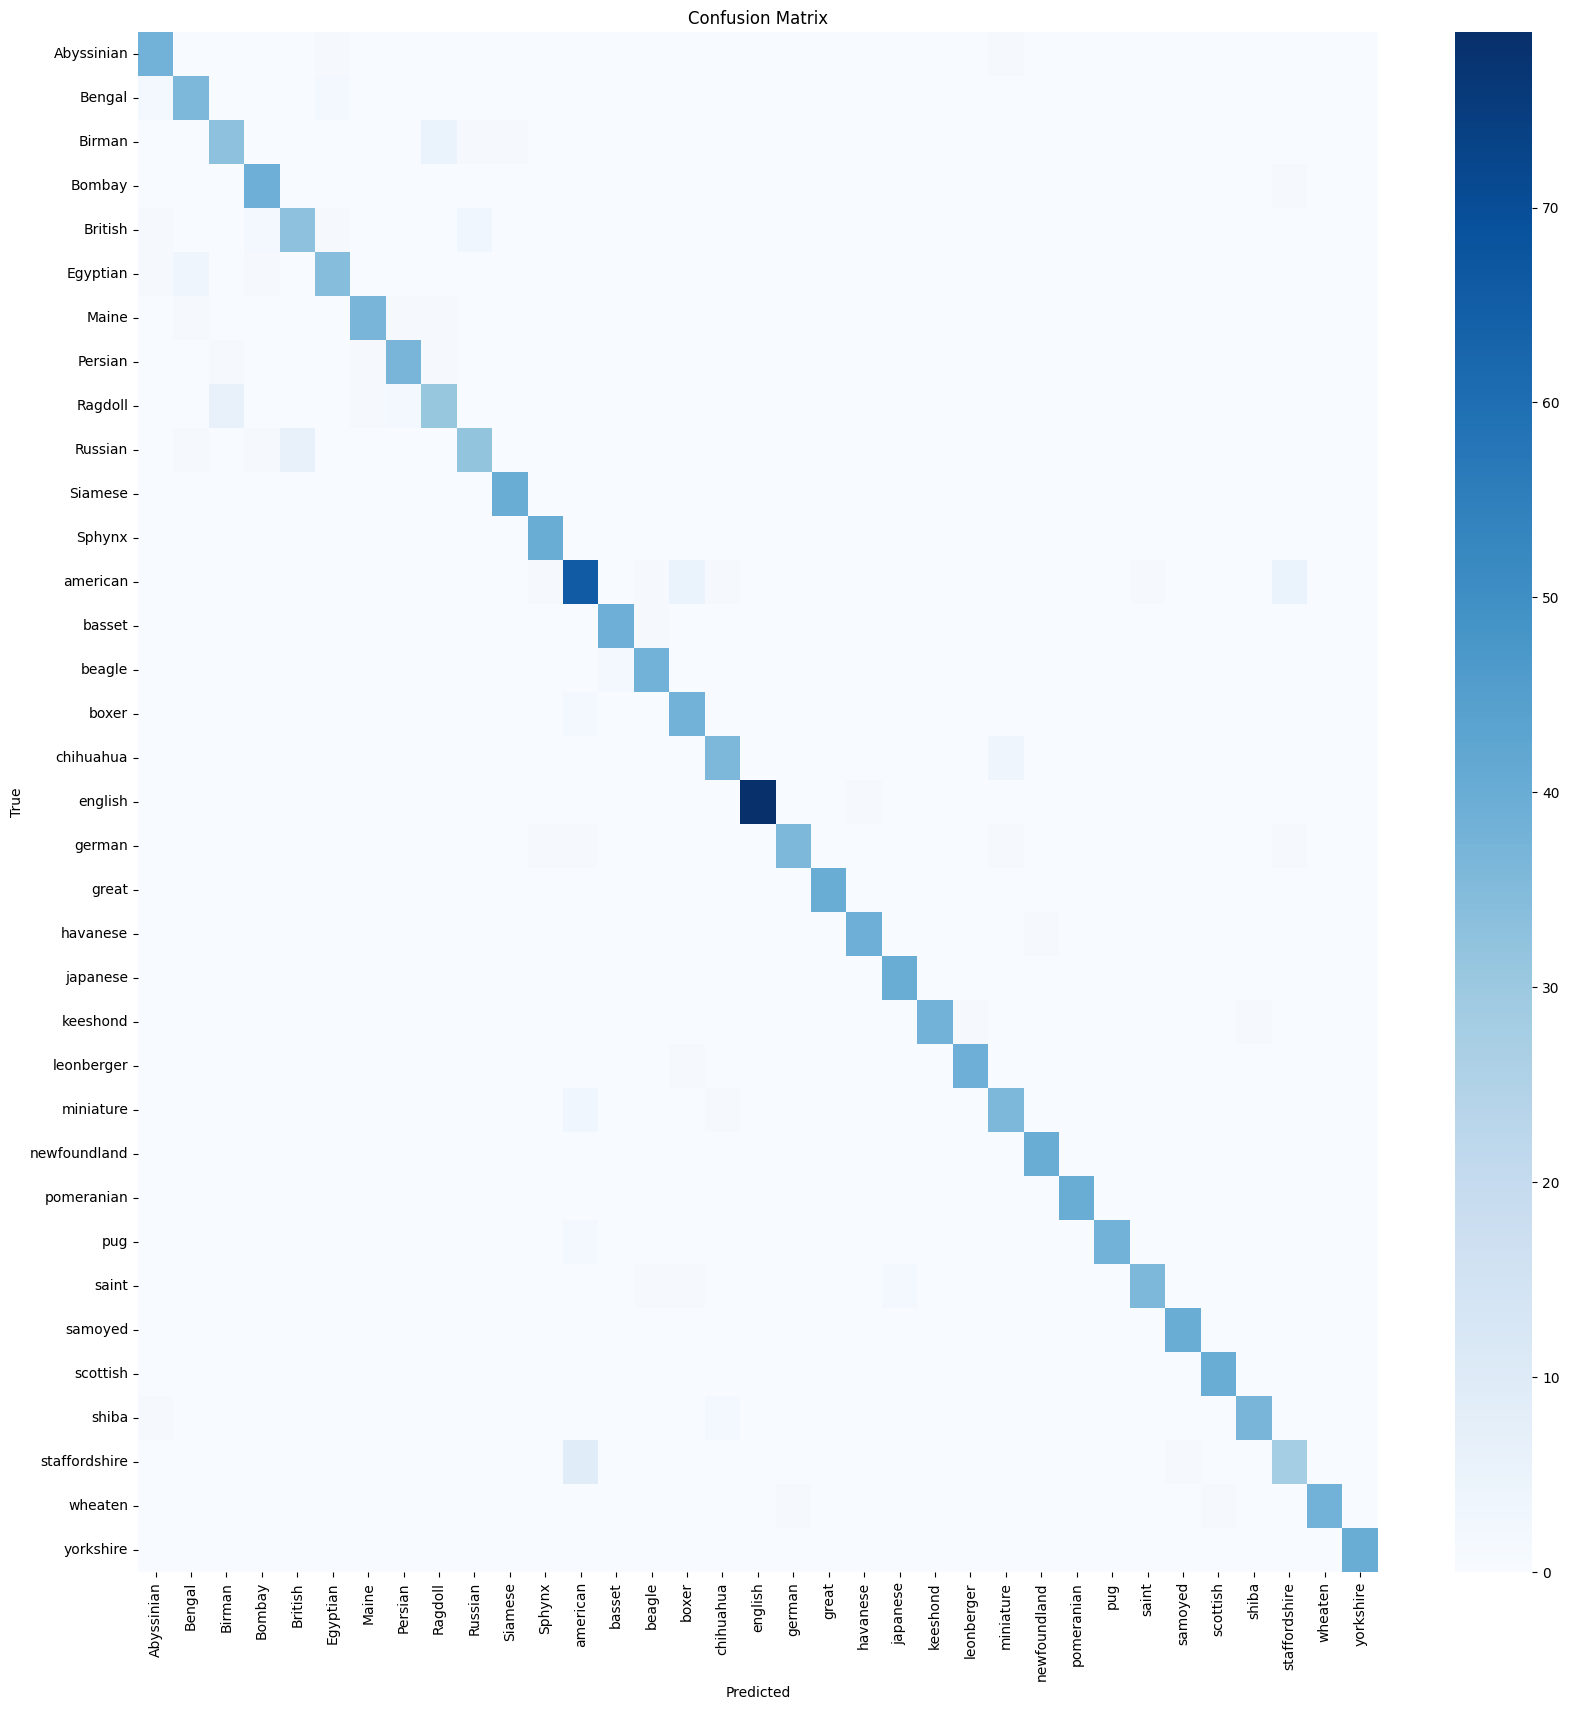

               precision    recall  f1-score   support

   Abyssinian       0.88      0.95      0.92        40
       Bengal       0.86      0.90      0.88        40
       Birman       0.82      0.82      0.82        40
       Bombay       0.91      0.97      0.94        40
      British       0.85      0.82      0.84        40
     Egyptian       0.89      0.85      0.87        40
        Maine       0.95      0.93      0.94        40
      Persian       0.93      0.93      0.93        40
      Ragdoll       0.82      0.78      0.79        40
      Russian       0.89      0.80      0.84        40
      Siamese       0.98      1.00      0.99        40
       Sphynx       0.95      1.00      0.98        40
     american       0.80      0.82      0.81        80
       basset       0.95      0.97      0.96        40
       beagle       0.93      0.95      0.94        40
        boxer       0.84      0.95      0.89        40
    chihuahua       0.90      0.90      0.90        40
      eng

In [16]:
def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(20, 20))
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

def calculate_topk_accuracy(outputs, labels, k=3):
    _, topk = outputs.topk(k, dim=1)
    correct = topk.eq(labels.view(-1, 1)).sum()
    return correct.item() / labels.size(0)

model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_outputs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        all_outputs.append(outputs.cpu())
        all_labels.append(labels)

all_outputs = torch.cat(all_outputs)
all_labels = torch.cat(all_labels)

cm = confusion_matrix(all_labels, torch.argmax(all_outputs, dim=1))
plot_confusion_matrix(cm, full_dataset.classes)

print(classification_report(all_labels, torch.argmax(all_outputs, dim=1),
                            target_names=full_dataset.classes))

top3_acc = calculate_topk_accuracy(all_outputs, all_labels, k=3)
print(f"Top-3 Accuracy: {top3_acc * 100:.2f}%")

In [17]:
class VGG16Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.vgg = models.vgg16(pretrained=True)

        for param in self.vgg.features.parameters():
            param.requires_grad = False

        self.vgg.classifier = nn.Sequential(
            nn.Linear(25088, 4096),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(4096, 1024),
            nn.ReLU(True),
            nn.Dropout(0.3),
            nn.Linear(1024, NUM_CLASSES)
        )

    def forward(self, x):
        return self.vgg(x)

device = torch.device("cuda")
model = VGG16Classifier().to(device)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:05<00:00, 95.5MB/s]


In [18]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.vgg.classifier.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2)

best_acc = 0.0

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total

    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = 100 * test_correct / test_total
    scheduler.step(test_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss/len(test_loader):.4f} | Acc: {test_acc:.2f}%")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "best_vgg_model.pth")
        print("Model saved!")

Epoch 1/15:   0%|          | 0/185 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 1/15: 100%|██████████| 185/185 [00:40<00:00,  4.55it/s]


Epoch 1:
Train Loss: 1.4329 | Acc: 63.63%
Test Loss: 0.6499 | Acc: 80.51%
Model saved!


Epoch 2/15: 100%|██████████| 185/185 [00:39<00:00,  4.63it/s]


Epoch 2:
Train Loss: 0.6208 | Acc: 83.20%
Test Loss: 0.5238 | Acc: 84.51%
Model saved!


Epoch 3/15: 100%|██████████| 185/185 [00:39<00:00,  4.63it/s]


...

Epoch 13:
Train Loss: 0.0737 | Acc: 98.33%
Test Loss: 0.6224 | Acc: 88.97%
Model saved!


Epoch 14/15: 100%|██████████| 185/185 [00:42<00:00,  4.31it/s]


Epoch 14:
Train Loss: 0.0857 | Acc: 98.27%
Test Loss: 0.6172 | Acc: 89.45%
Model saved!


Epoch 15/15: 100%|██████████| 185/185 [00:42<00:00,  4.40it/s]


Epoch 15:
Train Loss: 0.0695 | Acc: 98.53%
Test Loss: 0.6022 | Acc: 89.31%


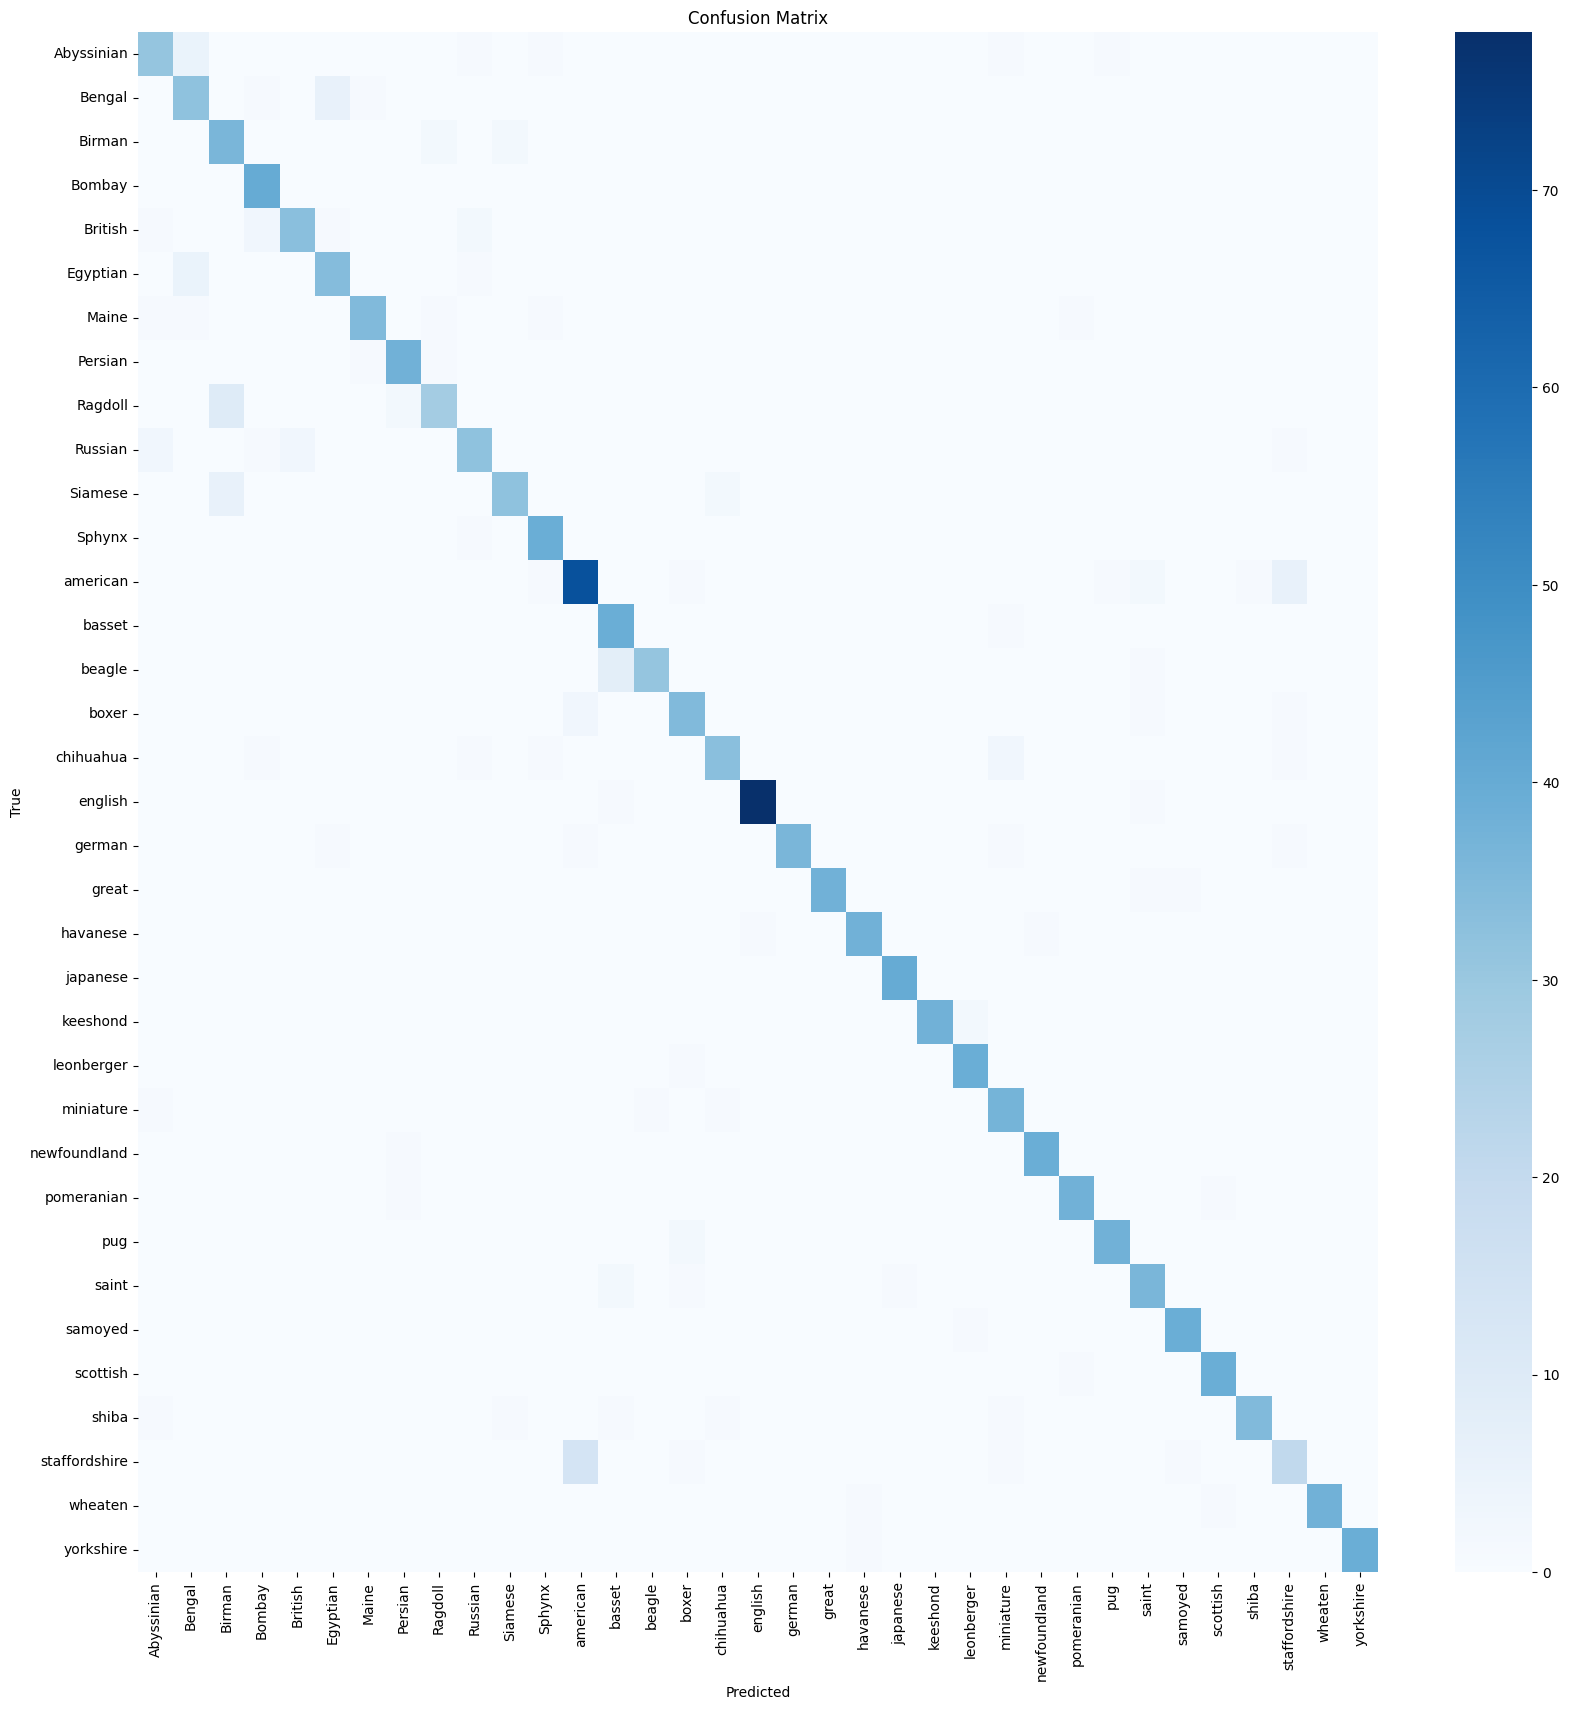

               precision    recall  f1-score   support

   Abyssinian       0.82      0.78      0.79        40
       Bengal       0.74      0.80      0.77        40
       Birman       0.69      0.90      0.78        40
       Bombay       0.87      1.00      0.93        40
      British       0.92      0.82      0.87        40
     Egyptian       0.81      0.85      0.83        40
        Maine       0.95      0.88      0.91        40
      Persian       0.90      0.95      0.93        40
      Ragdoll       0.88      0.70      0.78        40
      Russian       0.84      0.80      0.82        40
      Siamese       0.91      0.80      0.85        40
       Sphynx       0.91      0.97      0.94        40
     american       0.79      0.85      0.82        80
       basset       0.76      0.97      0.86        40
       beagle       0.97      0.78      0.86        40
        boxer       0.85      0.88      0.86        40
    chihuahua       0.89      0.82      0.86        40
      eng

In [19]:
def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(20, 20))
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

model.load_state_dict(torch.load("best_vgg_model.pth"))
model.eval()

all_outputs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        all_outputs.append(outputs.cpu())
        all_labels.append(labels)

all_outputs = torch.cat(all_outputs)
all_labels = torch.cat(all_labels)

cm = confusion_matrix(all_labels, torch.argmax(all_outputs, dim=1))
plot_confusion_matrix(cm, full_dataset.classes)

print(classification_report(all_labels, torch.argmax(all_outputs, dim=1),
                            target_names=full_dataset.classes))

_, top3_preds = torch.topk(all_outputs, 3, dim=1)
top3_correct = torch.sum(torch.tensor([label in preds for label, preds in zip(all_labels, top3_preds)]))
top3_accuracy = 100 * top3_correct / len(all_labels)
print(f"Top-3 Accuracy: {top3_accuracy:.2f}%")

In [20]:
class VGG19Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.vgg = models.vgg19(pretrained=True)

        for param in self.vgg.features.parameters():
            param.requires_grad = False

        self.vgg.classifier = nn.Sequential(
            nn.Linear(25088, 4096),
            nn.ReLU(True),
            nn.Dropout(0.5),
            nn.Linear(4096, 1024),
            nn.ReLU(True),
            nn.Dropout(0.3),
            nn.Linear(1024, NUM_CLASSES)
        )

    def forward(self, x):
        return self.vgg(x)

device = torch.device("cuda")
model = VGG19Classifier().to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:05<00:00, 100MB/s]


In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.vgg.classifier.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2)

best_acc = 0.0

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    train_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100 * correct / total

    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = 100 * test_correct / test_total
    scheduler.step(test_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss/len(test_loader):.4f} | Acc: {test_acc:.2f}%")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "best_vgg19_model.pth")
        print("Model saved!")

Epoch 1/15:   0%|          | 0/185 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 1/15: 100%|██████████| 185/185 [00:46<00:00,  3.95it/s]


Epoch 1:
Train Loss: 1.4361 | Acc: 66.62%
Test Loss: 0.4960 | Acc: 85.25%
Model saved!


Epoch 2/15: 100%|██████████| 185/185 [00:46<00:00,  3.97it/s]


Epoch 2:
Train Loss: 0.6423 | Acc: 83.30%
Test Loss: 0.8079 | Acc: 80.51%


Epoch 3/15: 100%|██████████| 185/185 [00:46<00:00,  4.01it/s]


...

Epoch 13:
Train Loss: 0.0439 | Acc: 98.68%
Test Loss: 0.4345 | Acc: 90.12%


Epoch 14/15: 100%|██████████| 185/185 [00:46<00:00,  3.96it/s]


Epoch 14:
Train Loss: 0.0377 | Acc: 98.83%
Test Loss: 0.4345 | Acc: 90.12%


Epoch 15/15: 100%|██████████| 185/185 [00:46<00:00,  4.00it/s]


Epoch 15:
Train Loss: 0.0342 | Acc: 99.02%
Test Loss: 0.4344 | Acc: 90.12%


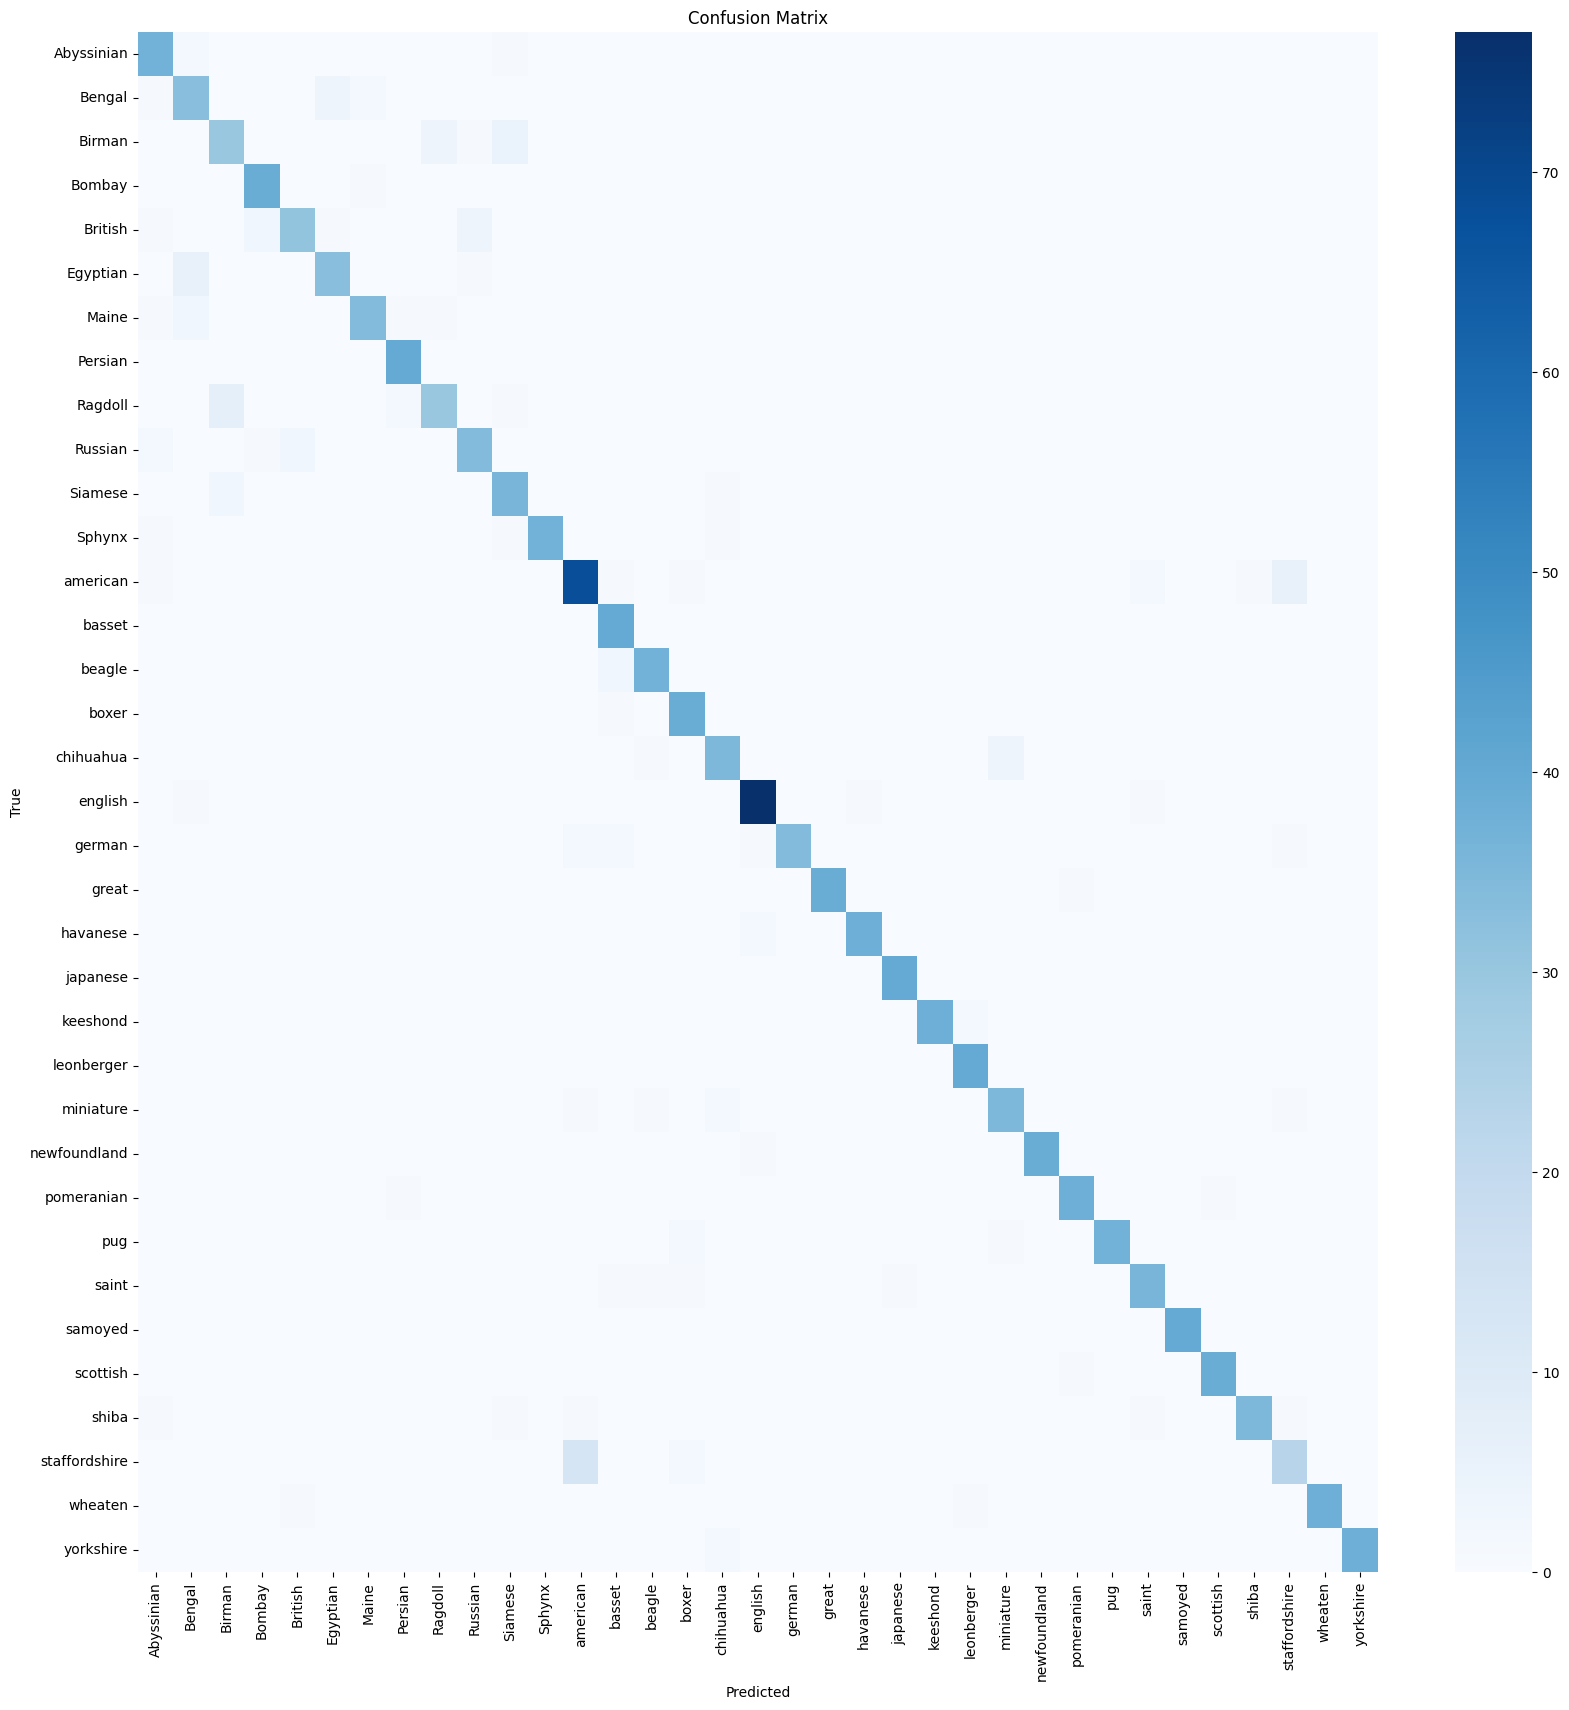

               precision    recall  f1-score   support

   Abyssinian       0.82      0.93      0.87        40
       Bengal       0.73      0.82      0.78        40
       Birman       0.75      0.75      0.75        40
       Bombay       0.91      0.97      0.94        40
      British       0.89      0.78      0.83        40
     Egyptian       0.87      0.82      0.85        40
        Maine       0.92      0.85      0.88        40
      Persian       0.91      1.00      0.95        40
      Ragdoll       0.86      0.75      0.80        40
      Russian       0.85      0.85      0.85        40
      Siamese       0.80      0.90      0.85        40
       Sphynx       1.00      0.93      0.96        40
     american       0.80      0.85      0.82        80
       basset       0.83      1.00      0.91        40
       beagle       0.93      0.93      0.93        40
        boxer       0.87      0.97      0.92        40
    chihuahua       0.85      0.88      0.86        40
      eng

In [22]:
def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(20, 20))
    sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

model.load_state_dict(torch.load("best_vgg19_model.pth"))
model.eval()

all_outputs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        all_outputs.append(outputs.cpu())
        all_labels.append(labels)

all_outputs = torch.cat(all_outputs)
all_labels = torch.cat(all_labels)


cm = confusion_matrix(all_labels, torch.argmax(all_outputs, dim=1))
plot_confusion_matrix(cm, full_dataset.classes)
print(classification_report(all_labels, torch.argmax(all_outputs, dim=1),
                            target_names=full_dataset.classes))
_, top3_preds = torch.topk(all_outputs, 3, dim=1)
top3_correct = torch.sum(torch.tensor([label in preds for label, preds in zip(all_labels, top3_preds)]))
top3_accuracy = 100 * top3_correct / len(all_labels)
print(f"Top-3 Accuracy: {top3_accuracy:.2f}%")

# Бинарная классификация ResNet

In [62]:
import torch
import numpy as np
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import StratifiedShuffleSplit

In [63]:
DATA_ROOT = "/content/new_images"
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_CLASSES = 37
device = torch.device("cuda")

In [64]:
class CustomResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = models.resnet50(pretrained=False)

        in_features = self.model.fc.in_features
        self.model.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 37)
        )

    def forward(self, x):
        return self.model(x)

In [65]:
device = torch.device("cuda")

model = CustomResNet()
model.load_state_dict(torch.load('best_model.pth'))
model = model.to(device)
model.eval()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


CustomResNet(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
       

In [66]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=DATA_ROOT, transform=transform)


In [67]:
labels = [label for _, label in full_dataset]
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_indices, test_indices = next(sss.split(np.zeros(len(labels)), labels))
test_dataset = Subset(full_dataset, test_indices)

In [71]:
binary_labels = torch.tensor([
    1 if full_dataset.targets[i] in [
    'Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair',
    'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue',
    'Siamese', 'Sphynx'] else 0
    for i in test_indices
])

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

correct = 0
total = 0

In [72]:
with torch.no_grad():
    for batch_idx, (images, _) in enumerate(test_loader):
        images = images.to(device)
        outputs = model(images)

        start_idx = batch_idx * BATCH_SIZE
        end_idx = start_idx + images.size(0)
        batch_labels = binary_labels[start_idx:end_idx].to(device)

        cat_logits = outputs[:, :12].sum(dim=1)
        dog_logits = outputs[:, 12:].sum(dim=1)
        predictions = (dog_logits > cat_logits).long()

        correct += (predictions == batch_labels).sum().item()
        total += images.size(0)

In [73]:
accuracy = correct / total
print(f'Бинарная точность (кошки vs собаки): {accuracy:.4f}')

Бинарная точность (кошки vs собаки): 0.9425
